In [1]:
!apt-get install -y clustalo
!pip install colabfold

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libargtable2-0
The following NEW packages will be installed:
  clustalo libargtable2-0
0 upgraded, 2 newly installed, 0 to remove and 37 not upgraded.
Need to get 273 kB of archives.
After this operation, 694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libargtable2-0 amd64 13-1.1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 clustalo amd64 1.2.4-7 [259 kB]
Fetched 273 kB in 2s (159 kB/s)
Selecting previously unselected package libargtable2-0.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting up

In [2]:
!pip install biopython==1.85 requests folium pandas matplotlib seaborn py3Dmol
!pip install -q "colabfold[alphafold] @ git+https://github.com/sokrypton/ColabFold"
!pip install -q --no-deps jax==0.4.23 jaxlib==0.4.23

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [4]:
import os
import time
import subprocess
import tempfile
import json
from collections import defaultdict
from urllib.parse import quote

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import requests
import folium
from folium.plugins import HeatMap
import py3Dmol

from Bio import Entrez, SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.PDB import alphafold_db, MMCIFParser
from IPython.display import HTML, display, Image

In [6]:
#WIDGET‑BASED CONFIGURATION
import ipywidgets as widgets
from IPython.display import display

# Flag to indicate configuration is done
config_done = False

# Create widgets
email_input = widgets.Text(description="Email:", placeholder="your.email@example.com")
hits_input = widgets.IntText(description="Max hits:", value=10)
seq_input = widgets.Textarea(description="Protein sequence:", placeholder="Paste sequence here", layout=widgets.Layout(width='100%', height='100px'))
button = widgets.Button(description="Set Configuration", button_style='success')
output = widgets.Output()

def on_button_clicked(b):
    global config_done, Entrez, MAX_HITS, QUERY_SEQUENCE
    with output:
        output.clear_output()
        Entrez.email = email_input.value.strip()
        if not Entrez.email:
            print("Email required.")
            config_done = False
            return
        MAX_HITS = hits_input.value
        QUERY_SEQUENCE = seq_input.value.strip().replace(' ', '')
        if not QUERY_SEQUENCE:
            print("Sequence required.")
            config_done = False
            return
        config_done = True
        print("✅ Configuration set! Now you can run the analysis cells.")
        print(f"Email: {Entrez.email}")
        print(f"Max hits: {MAX_HITS}")
        print(f"Sequence length: {len(QUERY_SEQUENCE)}")

button.on_click(on_button_clicked)
display(email_input, hits_input, seq_input, button, output)

Text(value='', description='Email:', placeholder='your.email@example.com')

IntText(value=10, description='Max hits:')

Textarea(value='', description='Protein sequence:', layout=Layout(height='100px', width='100%'), placeholder='…

Button(button_style='success', description='Set Configuration', style=ButtonStyle())

Output()

In [7]:
#BLAST
def run_blast(sequence):
    """Run BLASTp and return parsed results."""
    print("Running BLAST...")
    result_handle = NCBIWWW.qblast("blastp", "nr", sequence, hitlist_size=MAX_HITS*2)
    blast_records = NCBIXML.parse(result_handle)
    hits = []
    for record in blast_records:
        for alignment in record.alignments:
            for hsp in alignment.hsps:
                identity = hsp.identities / hsp.align_length
                if identity >= 0.7:
                    title = alignment.title
                    if '[' in title and ']' in title:
                        species = title.split('[')[-1].split(']')[0]
                    else:
                        species = title.split(',')[0].strip()
                    hits.append({
                        'accession': alignment.accession,
                        'title': title,
                        'species': species,
                        'identity': identity,
                        'length': hsp.align_length,
                        'query_seq': hsp.query,
                        'hit_seq': hsp.sbjct
                    })
    hits.sort(key=lambda x: x['identity'], reverse=True)
    return hits[:MAX_HITS]

#NCBI Taxonomy
def get_taxonomy(species_name):
    """Fetch taxonomic lineage from NCBI Taxonomy."""
    try:
        handle = Entrez.esearch(db="taxonomy", term=species_name)
        record = Entrez.read(handle)
        handle.close()
        if record["IdList"]:
            tax_id = record["IdList"][0]
            handle = Entrez.efetch(db="taxonomy", id=tax_id)
            tax_record = Entrez.read(handle)
            handle.close()
            lineage = tax_record[0]["Lineage"].split("; ")
            return {
                "kingdom": lineage[0] if len(lineage) > 0 else "",
                "phylum": lineage[1] if len(lineage) > 1 else "",
                "class": lineage[2] if len(lineage) > 2 else "",
                "order": lineage[3] if len(lineage) > 3 else "",
                "family": lineage[4] if len(lineage) > 4 else "",
                "genus": lineage[5] if len(lineage) > 5 else "",
                "species": tax_record[0]["ScientificName"]
            }
    except Exception as e:
        print(f"Taxonomy error for {species_name}: {e}")
    return {}

#iNaturalist Images
def get_inaturalist_images(species):
    """Fetch up to 3 image URLs from iNaturalist."""
    url = "https://api.inaturalist.org/v1/observations"
    params = {
        "taxon_name": species,
        "quality_grade": "research",
        "photos": True,
        "per_page": 3
    }
    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()
        images = []
        for obs in data.get('results', []):
            for photo in obs.get('photos', []):
                img_url = photo.get('url', '').replace('square', 'medium')
                if img_url:
                    images.append({
                        'url': img_url,
                        'attribution': photo.get('attribution', '')
                    })
        return images
    except Exception as e:
        print(f"iNaturalist error for {species}: {e}")
        return []

#iNaturalist Common Name
def get_inat_common_name(species):
    """Fetch common name from iNaturalist taxon API."""
    url = "https://api.inaturalist.org/v1/taxa"
    params = {"q": species}
    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()
        if data['total_results'] > 0:
            return data['results'][0].get('preferred_common_name', 'N/A')
    except Exception as e:
        print(f"iNaturalist taxon error for {species}: {e}")
    return 'N/A'

#GBIF Occurrences (with location)
def get_gbif_occurrences(species):
    """Fetch up to 50 occurrence coordinates and location names from GBIF."""
    url = "https://api.gbif.org/v1/occurrence/search"
    params = {
        "scientificName": species,
        "hasCoordinate": True,
        "limit": 50
    }
    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()
        occurrences = []
        for occ in data.get('results', []):
            lat = occ.get('decimalLatitude')
            lon = occ.get('decimalLongitude')
            if lat is not None and lon is not None:
                loc_parts = []
                if occ.get('country'): loc_parts.append(occ['country'])
                if occ.get('stateProvince'): loc_parts.append(occ['stateProvince'])
                if occ.get('locality'): loc_parts.append(occ['locality'])
                location_name = ', '.join(loc_parts) if loc_parts else 'Unknown location'
                occurrences.append({
                    'lat': lat,
                    'lon': lon,
                    'location': location_name
                })
        return occurrences
    except Exception as e:
        print(f"GBIF error for {species}: {e}")
        return []

#PubMed
def get_pubmed_articles(species, protein_name=""):
    """Search PubMed for articles about the species and toxin/protein."""
    query = f"{species}[Organism] AND (toxin OR venom OR {protein_name})"
    try:
        handle = Entrez.esearch(db="pubmed", term=query, retmax=5)
        record = Entrez.read(handle)
        handle.close()
        if not record["IdList"]:
            return []
        handle = Entrez.esummary(db="pubmed", id=",".join(record["IdList"]))
        summaries = Entrez.read(handle)
        handle.close()
        articles = []
        for doc in summaries:
            articles.append({
                'pmid': doc['Id'],
                'title': doc.get('Title', 'No title'),
                'authors': ', '.join(doc.get('AuthorList', [])),
                'journal': doc.get('FullJournalName', ''),
                'year': doc.get('PubDate', '').split()[0] if doc.get('PubDate') else ''
            })
        return articles
    except Exception as e:
        print(f"PubMed error: {e}")
        return []

#Clustal Omega
def run_clustalo(seq_dict):
    """Run Clustal Omega, return alignment and Newick tree."""
    import os, tempfile, subprocess
    with tempfile.NamedTemporaryFile(mode='w', suffix='.fasta', delete=False) as f_in:
        for seq_id, seq in seq_dict.items():
            f_in.write(f">{seq_id}\n{seq}\n")
        infile = f_in.name
    outfile = infile + ".aln"
    treefile = infile + ".dnd"
    try:
        cmd = ['clustalo', '-i', infile, '-o', outfile, '--guidetree-out', treefile, '--force']
        result = subprocess.run(cmd, check=False, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"Clustal Omega error: {result.stderr}")
            alignment = tree = ""
        else:
            alignment = open(outfile).read() if os.path.exists(outfile) else ""
            tree = open(treefile).read() if os.path.exists(treefile) else ""
    except Exception as e:
        print(f"Exception: {e}")
        alignment = tree = ""
    finally:
        for f in [infile, outfile, treefile]:
            if os.path.exists(f):
                os.unlink(f)
    return alignment, tree

print("setup loaded")

setup loaded


In [8]:
#GBIF Images
def get_gbif_images(species, max_images=3):
    """Fetch image URLs from GBIF for a given species."""
    try:
        taxon_url = f"https://api.gbif.org/v1/species/match?name={species}"
        taxon_response = requests.get(taxon_url, timeout=10)
        if taxon_response.status_code != 200:
            return []
        taxon_data = taxon_response.json()
        taxon_key = taxon_data.get('usageKey')
        if not taxon_key:
            return []
        images_url = f"https://api.gbif.org/v1/occurrence/search?media_type=StillImage&taxon_key={taxon_key}&limit={max_images}"
        img_response = requests.get(images_url, timeout=10)
        if img_response.status_code != 200:
            return []
        data = img_response.json()
        images = []
        for result in data.get('results', []):
            for media in result.get('media', []):
                if media.get('type') == 'StillImage':
                    images.append({
                        'url': media.get('identifier'),
                        'attribution': media.get('rightsHolder', media.get('publisher', 'GBIF'))
                    })
        return images
    except Exception as e:
        print(f"GBIF image error for {species}: {e}")
        return []

#GBIF Common Name
def get_gbif_common_name(species):
    """Fetch common name (vernacular) from GBIF."""
    try:
        match_url = f"https://api.gbif.org/v1/species/match?name={species}"
        resp = requests.get(match_url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            usage_key = data.get('usageKey')
            if usage_key:
                vern_url = f"https://api.gbif.org/v1/species/{usage_key}/vernacularNames"
                vern_resp = requests.get(vern_url, timeout=10)
                if vern_resp.status_code == 200:
                    vern_data = vern_resp.json()
                    for item in vern_data.get('results', []):
                        if item.get('language') == 'eng':
                            return item.get('vernacularName', 'N/A')
    except Exception as e:
        print(f"GBIF common name error for {species}: {e}")
    return 'N/A'

print("image functions loaded.")

image functions loaded.


In [9]:
#BLAST
hits = run_blast(QUERY_SEQUENCE)

if not hits:
    print("No hits with >70% identity found. Stopping.")
    # Create empty list to avoid errors later
    hits = []
else:
    print(f"Found {len(hits)} hits.")
    df_hits = pd.DataFrame([
        {"Species": h["species"], "Accession": h["accession"], "Identity": f"{h['identity']:.1%}"}
        for h in hits
    ])
    display(df_hits)

Running BLAST...
Found 10 hits.


,Species,Accession,Identity
0,Pan troglodytes,NP_000230,100.0%
1,Homo sapiens,AAA36188,99.3%
2,synthetic construct,AKI70658,99.3%
3,Gorilla gorilla,NP_001266591,99.3%
4,synthetic construct,BAG73364,99.3%
5,synthetic construct,AKI70659,99.3%
6,synthetic construct,AKI70661,99.3%
7,synthetic construct,AKI70660,99.3%
8,Pongo abelii,XP_002823550,98.0%
9,Nomascus leucogenys,XP_003259554,96.6%


In [10]:
# Build dictionaries for map hover tooltips
species_images = {}
species_common = {}

for hit in hits:
    sp = hit['species']
    print(f"Fetching GBIF data for {sp}...")
    images = get_gbif_images(sp)
    species_images[sp] = images[0]['url'] if images else None
    species_common[sp] = get_gbif_common_name(sp) or 'N/A'
    time.sleep(0.5)

print("Data fetching complete.")

Fetching GBIF data for Pan troglodytes...
Fetching GBIF data for Homo sapiens...
Fetching GBIF data for synthetic construct...
Fetching GBIF data for Gorilla gorilla...
Fetching GBIF data for synthetic construct...
Fetching GBIF data for synthetic construct...
Fetching GBIF data for synthetic construct...
Fetching GBIF data for synthetic construct...
Fetching GBIF data for Pongo abelii...
Fetching GBIF data for Nomascus leucogenys...
Data fetching complete.


In [11]:
#taxonomy and iNaturalist Images Table
if hits:
    taxonomy_dict = {}
    images_dict = defaultdict(list)
    common_names = {}
    table_rows = []

    for hit in hits:
        sp = hit['species']
        print(f"\nProcessing {sp}...")
        if sp not in taxonomy_dict:
            taxonomy_dict[sp] = get_taxonomy(sp)
        if sp not in common_names:
            common_names[sp] = get_inat_common_name(sp)
            time.sleep(0.3)
        if sp not in images_dict:
            images_dict[sp] = get_inaturalist_images(sp)
            time.sleep(0.5)
        img_html = ""
        if images_dict[sp]:
            img_html = f'<img src="{images_dict[sp][0]["url"]}" width="150" style="border-radius:5px;">'
        else:
            img_html = "No image"
        table_rows.append({
            "Species": sp,
            "Common Name": common_names[sp],
            "Image": img_html
        })

    if table_rows:
        df = pd.DataFrame(table_rows)
        display(HTML(df.to_html(escape=False, index=False)))
    if taxonomy_dict:
        tax_df = pd.DataFrame(taxonomy_dict).T
        print("\nTaxonomic summary:")
        display(tax_df)


Processing Pan troglodytes...

Processing Homo sapiens...

Processing synthetic construct...

Processing Gorilla gorilla...

Processing synthetic construct...

Processing synthetic construct...

Processing synthetic construct...

Processing synthetic construct...

Processing Pongo abelii...

Processing Nomascus leucogenys...


Species,Common Name,Image
Pan troglodytes,Chimpanzee,
Homo sapiens,Human,No image
synthetic construct,N/A,No image
Gorilla gorilla,Xanthoid Crabs,
synthetic construct,N/A,No image
synthetic construct,N/A,No image
synthetic construct,N/A,No image
synthetic construct,N/A,No image
Pongo abelii,Sumatran Orangutan,
Nomascus leucogenys,Northern White-cheeked Gibbon,



Taxonomic summary:


,kingdom,phylum,class,order,family,genus,species
Pan troglodytes,cellular organisms,Eukaryota,Opisthokonta,Metazoa,Eumetazoa,Bilateria,Pan troglodytes
Homo sapiens,cellular organisms,Eukaryota,Opisthokonta,Metazoa,Eumetazoa,Bilateria,Homo sapiens
synthetic construct,other entries,other sequences,artificial sequences,,,,synthetic construct
Gorilla gorilla,cellular organisms,Eukaryota,Opisthokonta,Metazoa,Eumetazoa,Bilateria,Gorilla gorilla
Pongo abelii,cellular organisms,Eukaryota,Opisthokonta,Metazoa,Eumetazoa,Bilateria,Pongo abelii
Nomascus leucogenys,cellular organisms,Eukaryota,Opisthokonta,Metazoa,Eumetazoa,Bilateria,Nomascus leucogenys


In [12]:
#Interactive Map
if not hits:
    print("No hits to process for map.")
else:
    occurrences_dict = {}
    all_coords = []

    for hit in hits:
        sp = hit['species']
        if sp not in occurrences_dict:
            occ_data = get_gbif_occurrences(sp)
            occurrences_dict[sp] = occ_data
            all_coords.extend([(o['lat'], o['lon']) for o in occ_data])
            time.sleep(0.5)

    if all_coords:
        mean_lat = sum(c[0] for c in all_coords) / len(all_coords)
        mean_lon = sum(c[1] for c in all_coords) / len(all_coords)
        m = folium.Map(location=[mean_lat, mean_lon], zoom_start=3)

        folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Esri', name='Satellite'
        ).add_to(m)

        for sp, occ_list in occurrences_dict.items():
            img_url = species_images.get(sp)
            common_name = species_common.get(sp, 'N/A')
            for occ in occ_list:
                if img_url:
                    tooltip_html = f"""
                    <div style="width:220px; min-height:80px;">
                        <img src="{img_url}" width="80" style="float:left; margin-right:8px; border-radius:5px;">
                        <b>{sp}</b><br><i>{common_name}</i><br><small>{occ['location']}</small>
                    </div>
                    """
                else:
                    tooltip_html = f"<b>{sp}</b><br>{occ['location']}"
                folium.CircleMarker(
                    [occ['lat'], occ['lon']], radius=3, color='red', fill=True,
                    tooltip=tooltip_html
                ).add_to(m)

        HeatMap(all_coords).add_to(m)
        folium.LayerControl().add_to(m)
        display(m)
    else:
        print("No geographic coordinates found.")

In [13]:
#PubMed Publications
if not hits:
    print("No hits to process.")
else:
    publications_dict = defaultdict(list)
    for hit in hits:
        sp = hit['species']
        if sp not in publications_dict:
            pubs = get_pubmed_articles(sp)
            publications_dict[sp] = pubs
            time.sleep(0.5)

    for sp, pubs in publications_dict.items():
        print(f"\n--- {sp} ---")
        if pubs:
            for pub in pubs:
                print(f"{pub['title']}\n  Authors: {pub['authors']}\n  Journal: {pub['journal']} ({pub['year']})\n  PMID: {pub['pmid']} | URL: https://pubmed.ncbi.nlm.nih.gov/{pub['pmid']}/")
        else:
            print("No publications found.")


--- Pan troglodytes ---
Molecular profiles of blood from numerous species that differ in sensitivity to acute inflammation.
  Authors: Gregory DJ, Han F, Li P, Gritsenko MA, Kyle J, Riley FE, Chavez D, Yotova V, Sindeaux RHM, Hawash MBF, Xu F, Hung LY, Hayden DL, Tompkins RG, Lanford RE, Kobzik L, Hellman J, Jacobs JM, Barreiro LB, Xiao W, Warren HS
  Journal: Molecular medicine (Cambridge, Mass.) (2024)
  PMID: 39730996 | URL: https://pubmed.ncbi.nlm.nih.gov/39730996/
Pharmacological and behavioral investigation of putative self-medicative plants in Budongo chimpanzee diets.
  Authors: Freymann E, Carvalho S, Garbe LA, Dwi Ghazhelia D, Hobaiter C, Huffman MA, Muhumuza G, Schulz L, Sempebwa D, Wald F, Yikii ER, Zuberbühler K, Schultz F
  Journal: PloS one (2024)
  PMID: 38900778 | URL: https://pubmed.ncbi.nlm.nih.gov/38900778/
Geophagy among East African Chimpanzees: consumed soils provide protection from plant secondary compounds and bioavailable iron.
  Authors: Pebsworth PA, Hillie

In [14]:
#Phylogenetic Tree
if not hits:
    print("No hits to process for phylogeny.")
else:
    seq_dict = {hit['accession']: hit['hit_seq'] for hit in hits}
    if len(seq_dict) < 2:
        print("Need at least two sequences to build a tree.")
    else:
        print("Running Clustal Omega...")
        alignment, tree = run_clustalo(seq_dict)
        if tree:
            print("\nPhylogenetic Tree (Newick):")
            print(tree)
            print("\nUpload to iTOL (https://itol.embl.de) for circular visualization.")
        else:
            print("Tree not generated.")
        if alignment:
            print("\nAlignment snippet:\n", alignment[:500] + "...")

Running Clustal Omega...

Phylogenetic Tree (Newick):
(
XP_003259554:0.0168787
,
(
XP_002823550:0.0134871
,
(
AKI70660:0.00670397
,
(
AKI70661:0.00665118
,
(
AKI70659:0.00654561
,
(
BAG73364:0.00633446
,
(
NP_001266591:0.00591216
,
(
AKI70658:0.00506757
,
(
NP_000230:0.00337838
,
AAA36188:0.00337838
):0.00168919
):0.000844595
):0.000422297
):0.000211149
):0.000105575
):5.27874e-05
):0.00678315
):0.00339157
)
;


Upload to iTOL (https://itol.embl.de) for circular visualization.

Alignment snippet:
 >NP_000230
MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGISLANWMCLAKWESGYNTRA
TNYNAGDRSTDYGIFQINSRYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRD
PQGIRAWVAWRNRCQNRDVRQYVQGCGV
>AAA36188
MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGMSLANWMCLAKWESGYNTRA
TNYNAGDRSTDYGIFQINSRYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRD
PQGIRAWVAWRNRCQNRDVRQYVQGCGV
>AKI70658
MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGISLANWMCLAKWESGYNTRA
TNYNAGDRSTDYGTFQINSRYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRD
PQGIRAWVAWRNRCQNRDVRQYVQGCGV
>NP_001266591


STRUCTURE ANALYSIS (with confidence tables & Ramachandran plots)

▶ Pan troglodytes (NP_000230)
  UniProt: P61626
  Pre-computed AlphaFold structure found
AlphaFold structure for Pan troglodytes


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

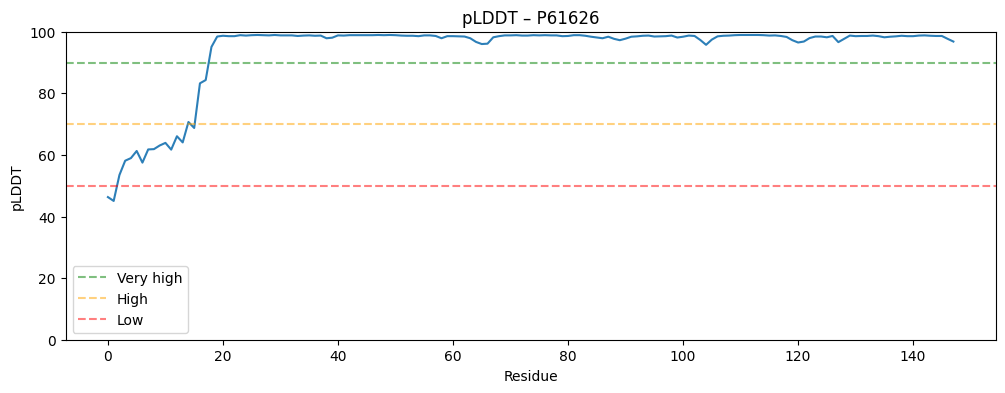


 pLDDT Confidence Table (first 20 residues):


,Residue,AA,pLDDT
0,1,MET,46.31
1,2,LYS,45.06
2,3,ALA,53.47
3,4,LEU,58.12
4,5,ILE,58.97
5,6,VAL,61.28
6,7,LEU,57.50
7,8,GLY,61.78
8,9,LEU,61.88
9,10,VAL,63.06


Full table saved to ./structures/P61626_plddt.csv

 Ramachandran Plot:


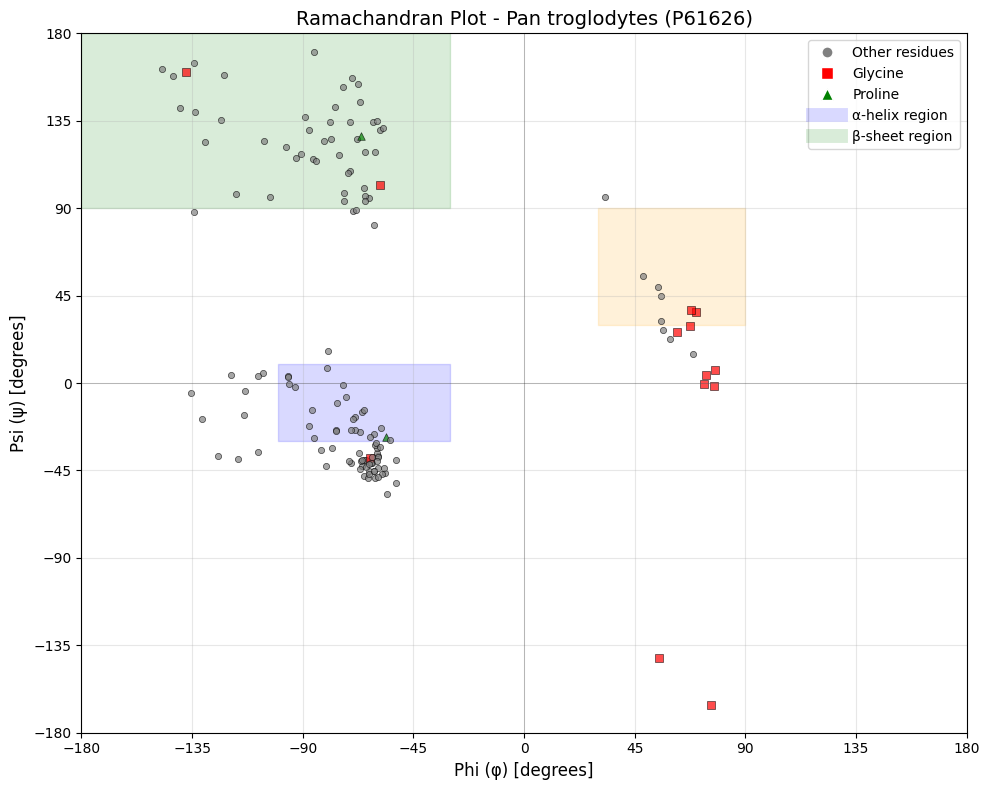

Total residues analyzed: 146
Residues in favored regions: 100 (68.5%)

▶ Homo sapiens (AAA36188)
  UniProt: P61626
File ./structures/AF-P61626-F1-model_v6.cif already exists, skipping download.
  Pre-computed AlphaFold structure found
AlphaFold structure for Homo sapiens


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

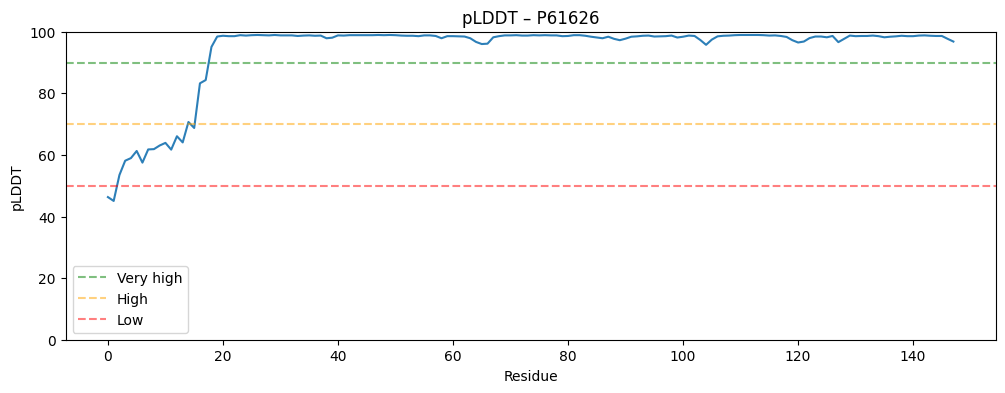


 pLDDT Confidence Table (first 20 residues):


,Residue,AA,pLDDT
0,1,MET,46.31
1,2,LYS,45.06
2,3,ALA,53.47
3,4,LEU,58.12
4,5,ILE,58.97
5,6,VAL,61.28
6,7,LEU,57.50
7,8,GLY,61.78
8,9,LEU,61.88
9,10,VAL,63.06


Full table saved to ./structures/P61626_plddt.csv

 Ramachandran Plot:


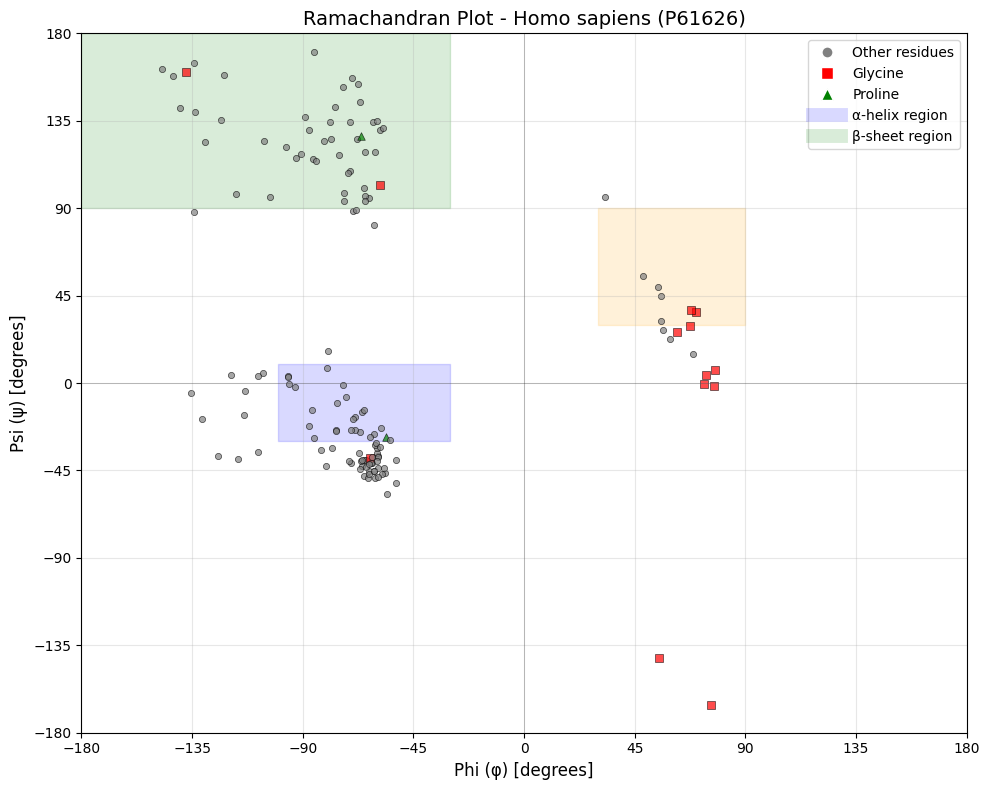

Total residues analyzed: 146
Residues in favored regions: 100 (68.5%)

▶ synthetic construct (AKI70658)
No UniProt mapping – falling back to ColabFold
  Running ColabFold for synthetic_construct (may take several minutes)...
  ColabFold error: Command '['colabfold_batch', '--amber', '--templates', '--num-recycle', '3', '--model-type', 'alphafold2_ptm', './cf_predictions/synthetic_construct.fasta', './cf_predictions']' returned non-zero exit status 1.

▶ Gorilla gorilla (NP_001266591)
  UniProt: P79179
  Pre-computed AlphaFold structure found
AlphaFold structure for Gorilla gorilla


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

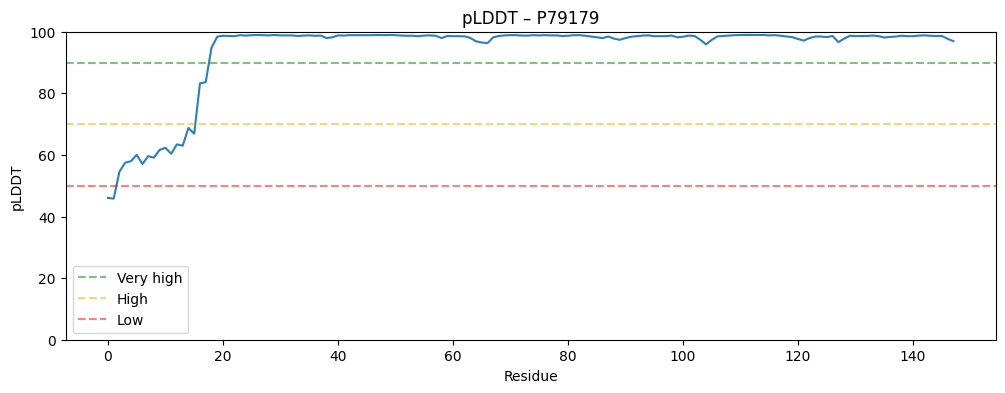


 pLDDT Confidence Table (first 20 residues):


,Residue,AA,pLDDT
0,1,MET,46.06
1,2,LYS,45.81
2,3,ALA,54.59
3,4,LEU,57.47
4,5,ILE,57.97
5,6,VAL,60.03
6,7,LEU,57.06
7,8,GLY,59.59
8,9,LEU,59.12
9,10,VAL,61.66


Full table saved to ./structures/P79179_plddt.csv

 Ramachandran Plot:


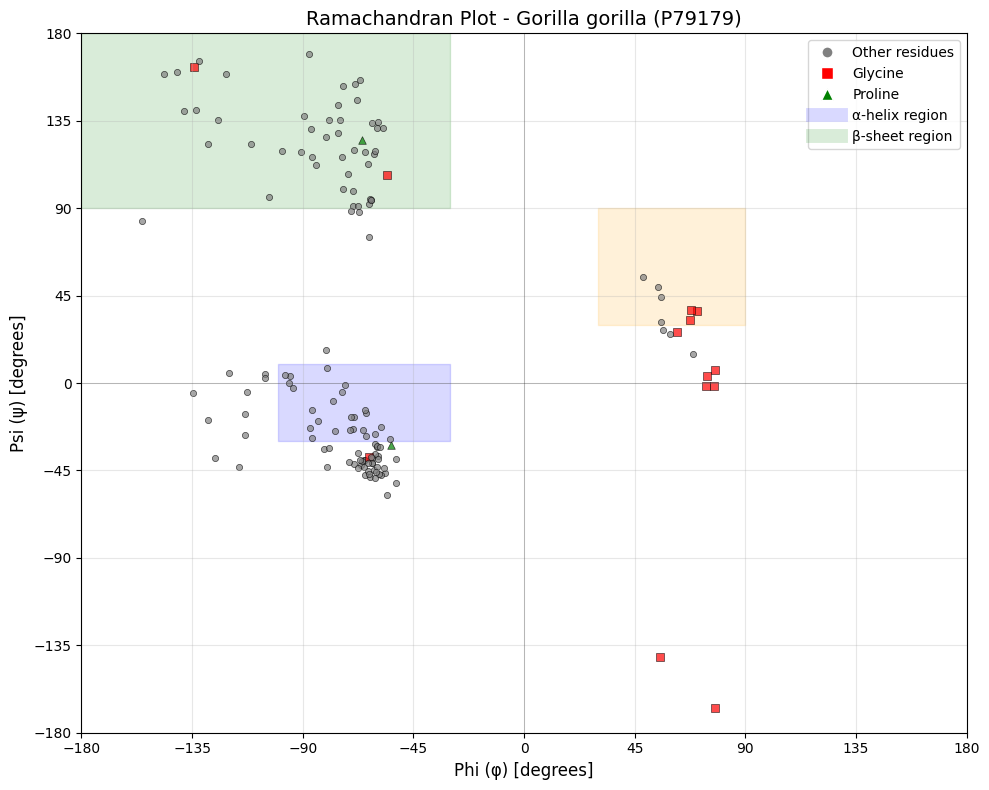

Total residues analyzed: 146
Residues in favored regions: 99 (67.8%)

▶ synthetic construct (BAG73364)
No UniProt mapping – falling back to ColabFold
  Running ColabFold for synthetic_construct (may take several minutes)...
  ColabFold error: Command '['colabfold_batch', '--amber', '--templates', '--num-recycle', '3', '--model-type', 'alphafold2_ptm', './cf_predictions/synthetic_construct.fasta', './cf_predictions']' returned non-zero exit status 1.

▶ synthetic construct (AKI70659)
No UniProt mapping – falling back to ColabFold
  Running ColabFold for synthetic_construct (may take several minutes)...
  ColabFold error: Command '['colabfold_batch', '--amber', '--templates', '--num-recycle', '3', '--model-type', 'alphafold2_ptm', './cf_predictions/synthetic_construct.fasta', './cf_predictions']' returned non-zero exit status 1.

▶ synthetic construct (AKI70661)
No UniProt mapping – falling back to ColabFold
  Running ColabFold for synthetic_construct (may take several minutes)...
  Cola

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

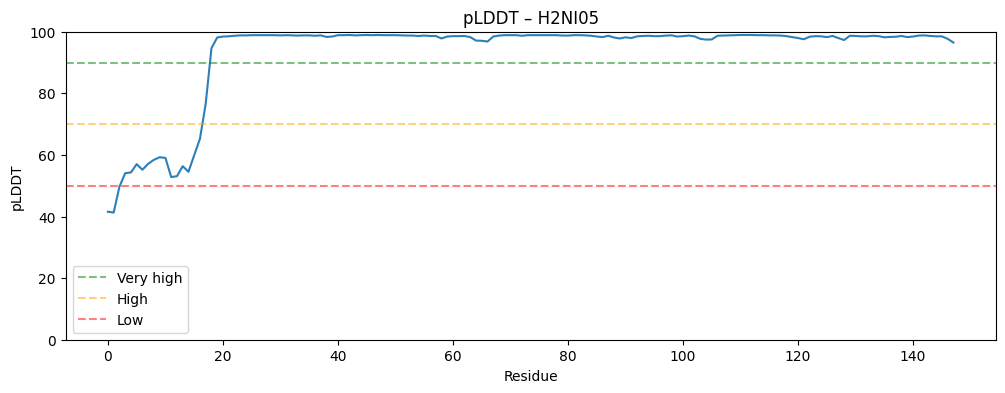


 pLDDT Confidence Table (first 20 residues):


,Residue,AA,pLDDT
0,1,MET,41.56
1,2,LYS,41.28
2,3,ALA,49.69
3,4,LEU,54.06
4,5,ILE,54.31
5,6,ILE,57.00
6,7,LEU,55.19
7,8,GLY,57.12
8,9,LEU,58.41
9,10,VAL,59.25


Full table saved to ./structures/H2NI05_plddt.csv

 Ramachandran Plot:


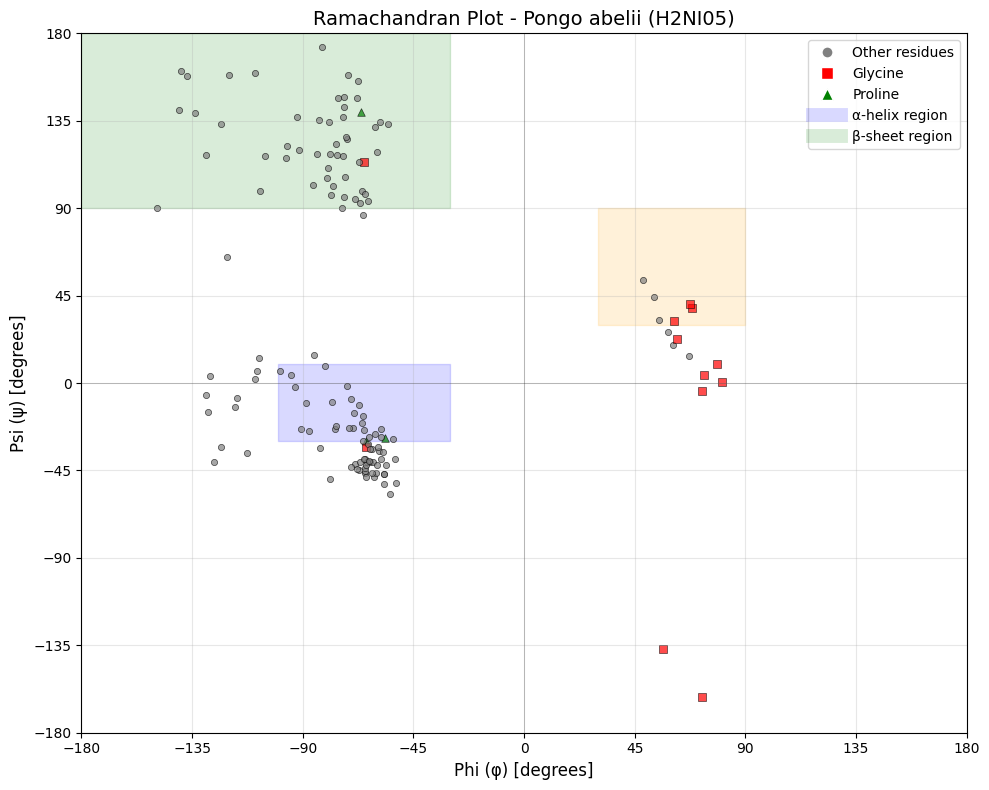

Total residues analyzed: 146
Residues in favored regions: 102 (69.9%)

▶ Nomascus leucogenys (XP_003259554)
  UniProt: G1QUK3
  Pre-computed AlphaFold structure found
AlphaFold structure for Nomascus leucogenys


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

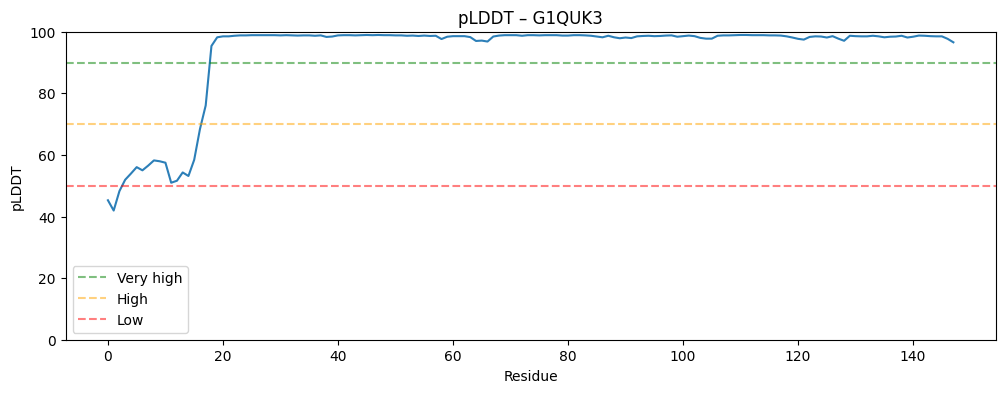


 pLDDT Confidence Table (first 20 residues):


,Residue,AA,pLDDT
0,1,MET,45.28
1,2,LYS,41.94
2,3,ALA,48.25
3,4,LEU,51.94
4,5,ILE,53.94
5,6,ILE,56.03
6,7,LEU,55.00
7,8,GLY,56.53
8,9,LEU,58.22
9,10,VAL,57.94


Full table saved to ./structures/G1QUK3_plddt.csv

 Ramachandran Plot:


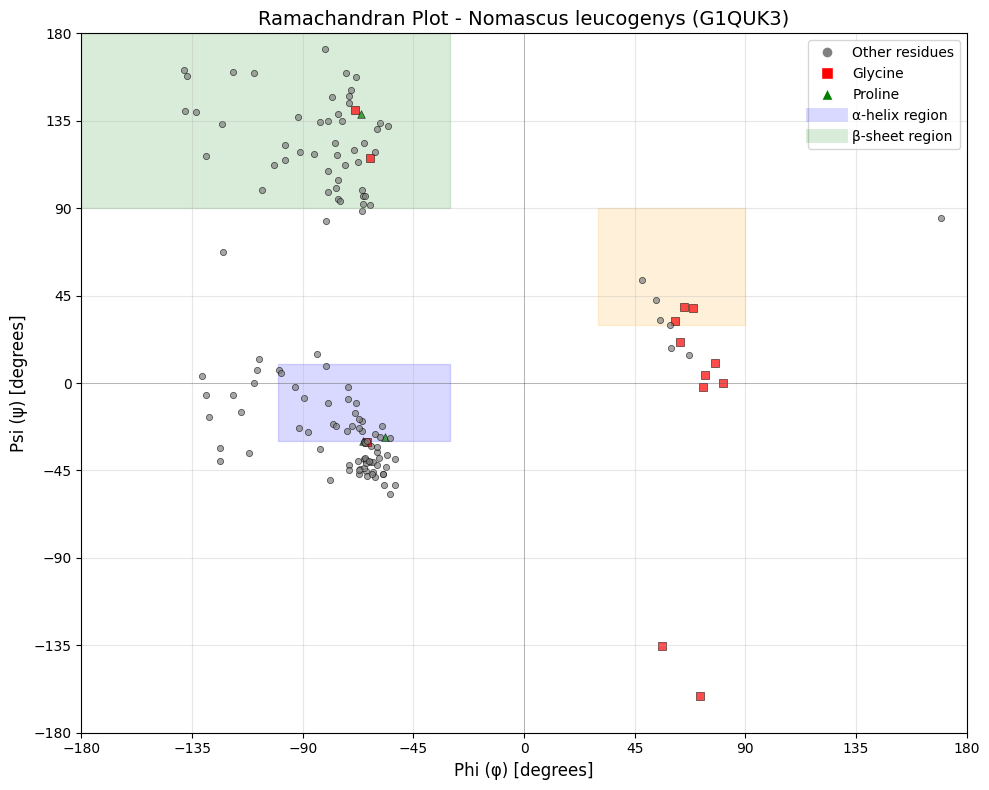

Total residues analyzed: 146
Residues in favored regions: 103 (70.5%)


In [15]:
#Structure Analysis with pLDDT Table & Ramachandran Plot

def get_uniprot_from_accession(accession):
    """Map any protein accession to UniProt ID."""
    if accession.startswith(('NP_', 'XP_', 'YP_')):
        from_db = 'RefSeq_Protein'
    else:
        from_db = 'EMBL-GenBank-DDBJ_CDS'
    url = "https://rest.uniprot.org/idmapping/run"
    data = {'from': from_db, 'to': 'UniProtKB', 'ids': accession}
    try:
        resp = requests.post(url, data=data, timeout=30)
        resp.raise_for_status()
        job_id = resp.json().get('jobId')
        if not job_id:
            return None
        time.sleep(2)
        result_url = f"https://rest.uniprot.org/idmapping/stream/{job_id}"
        result_resp = requests.get(result_url, timeout=30)
        result_resp.raise_for_status()
        results = result_resp.json().get('results', [])
        return results[0]['to'] if results else None
    except:
        return None

def check_alphafold_db(uniprot_id, out_dir='./structures'):
    os.makedirs(out_dir, exist_ok=True)
    try:
        predictions = list(alphafold_db.get_predictions(uniprot_id))
        if not predictions:
            return None
        pred = predictions[0]
        af_id = pred['entryId']
        cif_path = alphafold_db.download_cif_for(pred, directory=out_dir)
        pae_url = f"https://alphafold.ebi.ac.uk/files/{af_id}-predicted_aligned_error_v4.json"
        pae_path = None
        if requests.head(pae_url).status_code == 200:
            pae_data = requests.get(pae_url).text
            pae_path = os.path.join(out_dir, f"{af_id}_pae.json")
            with open(pae_path, 'w') as f:
                f.write(pae_data)
        return {'cif_path': cif_path, 'pae_path': pae_path, 'alphafold_id': af_id}
    except:
        return None

def display_cif(cif_path, title=""):
    with open(cif_path) as f:
        cif_data = f.read()
    view = py3Dmol.view(width=800, height=400)
    view.addModel(cif_data, 'cif')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()
    if title:
        print(title)
    return view.show()

def plot_plddt(cif_path, uniprot_id):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure('protein', cif_path)
    plddt = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    plddt.append(residue['CA'].get_bfactor())
    plt.figure(figsize=(12,4))
    plt.plot(plddt, color='#2c7fb8')
    plt.axhline(90, color='green', ls='--', alpha=0.5, label='Very high')
    plt.axhline(70, color='orange', ls='--', alpha=0.5, label='High')
    plt.axhline(50, color='red', ls='--', alpha=0.5, label='Low')
    plt.ylim(0,100)
    plt.xlabel('Residue')
    plt.ylabel('pLDDT')
    plt.title(f'pLDDT – {uniprot_id}')
    plt.legend()
    plt.show()

def plot_pae(pae_path, uniprot_id):
    if not pae_path or not os.path.exists(pae_path):
        return
    with open(pae_path) as f:
        pae_data = json.load(f)
    pae_mat = np.array(pae_data[0]['predicted_aligned_error'])
    plt.figure(figsize=(7,6))
    plt.imshow(pae_mat, cmap='viridis_r', vmin=0, vmax=30)
    plt.colorbar(label='PAE (Å)')
    plt.title(f'PAE – {uniprot_id}')
    plt.xlabel('Residue')
    plt.ylabel('Residue')
    plt.show()

def run_colabfold(sequence, name, out_dir='./cf_predictions'):
    import subprocess, glob
    os.makedirs(out_dir, exist_ok=True)
    fasta = os.path.join(out_dir, f"{name}.fasta")
    with open(fasta, 'w') as f:
        f.write(f">{name}\n{sequence}\n")
    cmd = [
        'colabfold_batch',
        '--amber', '--templates', '--num-recycle', '3',
        '--model-type', 'alphafold2_ptm',
        fasta, out_dir
    ]
    print(f"  Running ColabFold for {name} (may take several minutes)...")
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
        pdb_files = glob.glob(os.path.join(out_dir, f"{name}_unrelaxed_rank_*.pdb"))
        return pdb_files[0] if pdb_files else None
    except Exception as e:
        print(f"  ColabFold error: {e}")
        return None

#pLDDT Table
def create_plddt_table(cif_path, uniprot_id):
    """Extract residue-wise pLDDT and return as a pandas DataFrame."""
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure('protein', cif_path)
    data = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    res_num = residue.id[1]
                    res_name = residue.resname
                    plddt = residue['CA'].get_bfactor()
                    data.append([res_num, res_name, plddt])
    df = pd.DataFrame(data, columns=['Residue', 'AA', 'pLDDT'])
    return df

#Ramachandran Plot
from Bio.PDB import is_aa, CaPPBuilder

def plot_ramachandran(structure_file, file_format='cif', title=""):
    """
    Generate a Ramachandran plot from a structure file (PDB or mmCIF).
    """
    if file_format.lower() == 'pdb':
        parser = PDBParser(QUIET=True)
    else:
        parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure('protein', structure_file)

    phi_psi_data = []  # (phi, psi, resname)
    for model in structure:
        for chain in model:
            ppb = CaPPBuilder()
            for poly in ppb.build_peptides(chain):
                phi_psi = poly.get_phi_psi_list()
                for i, (phi, psi) in enumerate(phi_psi):
                    if phi is not None and psi is not None:
                        res = poly[i]
                        if is_aa(res):
                            phi_psi_data.append((np.degrees(phi), np.degrees(psi), res.resname))

    if not phi_psi_data:
        print("No phi/psi angles could be extracted.")
        return

    fig, ax = plt.subplots(figsize=(10, 8))
    #Background regions
    ax.fill_betweenx([-30, 10], -100, -30, alpha=0.15, color='blue', label='α-helix region')
    ax.fill_between([-180, -30], 90, 180, alpha=0.15, color='green', label='β-sheet region')
    ax.fill_between([30, 90], 30, 90, alpha=0.15, color='orange', label='Left-handed helix')

    colors = {'ALA': 'blue', 'GLY': 'red', 'PRO': 'green', 'others': 'gray'}
    for phi, psi, resname in phi_psi_data:
        if resname == 'GLY':
            color, marker, size = colors['GLY'], 's', 30
        elif resname == 'PRO':
            color, marker, size = colors['PRO'], '^', 30
        else:
            color, marker, size = colors['others'], 'o', 20
        ax.scatter(phi, psi, c=color, marker=marker, s=size, alpha=0.7, edgecolors='black', linewidth=0.5)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Other residues',
               markerfacecolor='gray', markersize=8),
        Line2D([0], [0], marker='s', color='w', label='Glycine',
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='^', color='w', label='Proline',
               markerfacecolor='green', markersize=8),
        Line2D([0], [0], color='blue', alpha=0.15, linewidth=10, label='α-helix region'),
        Line2D([0], [0], color='green', alpha=0.15, linewidth=10, label='β-sheet region'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    ax.set_xlabel('Phi (φ) [degrees]', fontsize=12)
    ax.set_ylabel('Psi (ψ) [degrees]', fontsize=12)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(np.arange(-180, 181, 45))
    ax.set_yticks(np.arange(-180, 181, 45))

    if title:
        ax.set_title(f'Ramachandran Plot - {title}', fontsize=14)
    else:
        ax.set_title('Ramachandran Plot', fontsize=14)
    plt.tight_layout()
    plt.show()

    total = len(phi_psi_data)
    favored = sum(1 for phi, psi, _ in phi_psi_data
                  if (-120 <= phi <= -40 and 80 <= psi <= 180) or
                     (-100 <= phi <= -30 and -70 <= psi <= -10))
    print(f"Total residues analyzed: {total}")
    print(f"Residues in favored regions: {favored} ({favored/total*100:.1f}%)")

#Main Structure Analysis Loop
print("\n" + "="*60)
print("STRUCTURE ANALYSIS (with confidence tables & Ramachandran plots)")
print("="*60)

os.makedirs('./structures', exist_ok=True)
os.makedirs('./cf_predictions', exist_ok=True)

for hit in hits:
    sp = hit['species']
    acc = hit['accession']
    seq = hit['hit_seq']
    print(f"\n▶ {sp} ({acc})")

    # 1. Map to UniProt
    uniprot = get_uniprot_from_accession(acc)
    if not uniprot:
        print("No UniProt mapping – falling back to ColabFold")
        pdb = run_colabfold(seq, sp.replace(' ', '_'))
        if pdb:
            display_cif(pdb, f"ColabFold prediction for {sp}")
            # Ramachandran plot for PDB
            print("\n Ramachandran Plot:")
            plot_ramachandran(pdb, file_format='pdb', title=f"{sp} (ColabFold)")
        continue

    print(f"  UniProt: {uniprot}")

    # 2. Check AlphaFold DB
    af = check_alphafold_db(uniprot)
    if af:
        print(f"  Pre-computed AlphaFold structure found")
        display_cif(af['cif_path'], f"AlphaFold structure for {sp}")

        # pLDDT plot
        plot_plddt(af['cif_path'], uniprot)

        # pLDDT table
        print("\n pLDDT Confidence Table (first 20 residues):")
        df_plddt = create_plddt_table(af['cif_path'], uniprot)
        display(df_plddt.head(20))
        # Optional: save full table as CSV
        csv_path = f"./structures/{uniprot}_plddt.csv"
        df_plddt.to_csv(csv_path, index=False)
        print(f"Full table saved to {csv_path}")

        # PAE plot if available
        if af.get('pae_path'):
            plot_pae(af['pae_path'], uniprot)

        # Ramachandran plot
        print("\n Ramachandran Plot:")
        plot_ramachandran(af['cif_path'], file_format='cif', title=f"{sp} ({uniprot})")

    else:
        print(f"  → No AlphaFold entry, running ColabFold...")
        pdb = run_colabfold(seq, sp.replace(' ', '_'))
        if pdb:
            display_cif(pdb, f"ColabFold prediction for {sp}")
            # For ColabFold, we can also generate a pLDDT table if needed (scores are in B-factor column of PDB)
            # But for simplicity, we'll just add Ramachandran
            print("\n Ramachandran Plot:")
            plot_ramachandran(pdb, file_format='pdb', title=f"{sp} (ColabFold)")

# At the end of Cell 13, after all processing:
analysis_completed = True   # Set this if everything worked

In [16]:
#DOWNLOAD ALL RESULTS
from google.colab import files as colab_files
import zipfile
import os
import time
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML
import base64

def create_download_zip():
    zip_name = "Seq2Bio_results.zip"
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        # 1. BLAST hits
        if 'hits' in globals() and hits:
            df_blast = pd.DataFrame([
                {"Species": h["species"], "Accession": h["accession"], "Identity": f"{h['identity']:.1%}"}
                for h in hits
            ])
            df_blast.to_csv("blast_results.csv", index=False)
            zipf.write("blast_results.csv")
            os.remove("blast_results.csv")

        # 2. Taxonomy
        if 'taxonomy_dict' in globals() and taxonomy_dict:
            df_tax = pd.DataFrame(taxonomy_dict).T
            df_tax.to_csv("taxonomy.csv")
            zipf.write("taxonomy.csv")
            os.remove("taxonomy.csv")

        # 3. Images (URLs + common names)
        if 'species_images' in globals() and species_images:
            img_rows = []
            for sp, url in species_images.items():
                img_rows.append({
                    "Species": sp,
                    "Image_URL": url if url else "None",
                    "Common_Name": species_common.get(sp, "N/A")
                })
            df_img = pd.DataFrame(img_rows)
            df_img.to_csv("images.csv", index=False)
            zipf.write("images.csv")
            os.remove("images.csv")

        # 4. Occurrences
        if 'occurrences_dict' in globals() and occurrences_dict:
            occ_rows = []
            for sp, occ_list in occurrences_dict.items():
                for occ in occ_list:
                    occ_rows.append({
                        "Species": sp,
                        "Latitude": occ['lat'],
                        "Longitude": occ['lon'],
                        "Location": occ['location']
                    })
            df_occ = pd.DataFrame(occ_rows)
            df_occ.to_csv("occurrences.csv", index=False)
            zipf.write("occurrences.csv")
            os.remove("occurrences.csv")

        # 5. Publications
        if 'publications_dict' in globals() and publications_dict:
            pub_rows = []
            for sp, pubs in publications_dict.items():
                for pub in pubs:
                    pub_rows.append({
                        "Species": sp,
                        "PMID": pub['pmid'],
                        "Title": pub['title'],
                        "Authors": pub['authors'],
                        "Journal": pub['journal'],
                        "Year": pub['year']
                    })
            df_pub = pd.DataFrame(pub_rows)
            df_pub.to_csv("publications.csv", index=False)
            zipf.write("publications.csv")
            os.remove("publications.csv")

        # 6. Phylogenetic tree
        if 'tree' in globals() and tree:
            with open("phylogenetic_tree.nwk", "w") as f:
                f.write(tree)
            zipf.write("phylogenetic_tree.nwk")
            os.remove("phylogenetic_tree.nwk")

        # 7. Structure files (from ./structures and ./cf_predictions)
        struct_dirs = ['./structures', './cf_predictions']
        for d in struct_dirs:
            if os.path.exists(d):
                for root, dirs, files in os.walk(d):
                    for file in files:
                        file_path = os.path.join(root, file)
                        arcname = os.path.relpath(file_path, start='.')
                        zipf.write(file_path, arcname)

        # 8. README
        readme = """Seq2Bio Results Archive
========================
This archive contains all results generated by the Seq2Bio pipeline.

Files included:
- blast_results.csv      : BLAST hits with species, accession, identity.
- taxonomy.csv            : Taxonomic lineage for each species.
- images.csv              : Image URLs and common names.
- occurrences.csv         : Geographic occurrence coordinates and locations.
- publications.csv        : PubMed articles related to each species.
- phylogenetic_tree.nwk   : Newick tree file.
- structures/             : Folder with downloaded AlphaFold structures or ColabFold predictions (CIF/PDB, PAE JSON, pLDDT CSV, plots).
- cf_predictions/         : Additional ColabFold predictions (if any).

For questions, contact the author.
"""
        with open("README.txt", "w") as f:
            f.write(readme)
        zipf.write("README.txt")
        os.remove("README.txt")

    # Wait a moment to ensure the file is fully written
    time.sleep(1)

    # Check file size
    if os.path.exists(zip_name) and os.path.getsize(zip_name) > 0:
        size_mb = os.path.getsize(zip_name) / (1024 * 1024)
        print(f" ZIP file size: {size_mb:.2f} MB")

        # Try automatic download
        print(" Triggering automatic download...")
        colab_files.download(zip_name)
        print("If download doesn't start automatically, use the link below.")

        # Also create a direct download link as fallback
        with open(zip_name, 'rb') as f:
            data = f.read()
        b64 = base64.b64encode(data).decode()
        href = f'<a href="data:application/zip;base64,{b64}" download="{zip_name}" style="font-size:16px; background-color:#4CAF50; color:white; padding:10px 20px; text-decoration:none; border-radius:5px;">📥 Click here to download {zip_name} (fallback)</a>'
        display(HTML(href))

        # Optionally remove the zip after download link is generated (comment out if you want to keep it)
        # os.remove(zip_name)
    else:
        print("ZIP file is empty or not found. No data to download.")

# Create a button to trigger download
button = widgets.Button(description="Download All Results", button_style='success')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        print("Creating ZIP archive...")
        create_download_zip()

button.on_click(on_button_clicked)
display(button, output)

Button(button_style='success', description='Download All Results', style=ButtonStyle())

Output()

In [19]:
from google.colab import userdata
import smtplib
from email.message import EmailMessage

def test_email():
    sender = userdata.get('EMAIL_ADDRESS')
    password = userdata.get('EMAIL_PASSWORD')
    RECIPIENT_EMAIL = Entrez.email  # change to desired address
    print(f"Email: {sender}")
    print(f"Password exists: {'Yes' if password else 'No'}")

    msg = EmailMessage()
    msg['Subject'] = 'Seq2Bio Analysis Successfully Completed'
    msg['From'] = sender
    msg['To'] = RECIPIENT_EMAIL
    msg.set_content(""" Dear User,

We are pleased to inform you that your protein sequence analysis using the Seq2Bio platform has been successfully completed.

Your results are now ready and available for download directly from the Seq2Bio platform. You can access your comprehensive analysis report, which includes:

1. BLAST homology search results

2. Taxonomic lineage information

3. Organism images and common names

4. Geographic occurrence maps

5. Relevant PubMed publications

6. Phylogenetic tree data

7. Protein structure predictions (where available)

Thank you for choosing Seq2Bio for your research. We hope the results provided will be valuable for your work.

If you have any questions, encounter any issues accessing your results, or would like to provide feedback, please do not hesitate to contact us.

Best regards,

The Seq2Bio Team """)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:
        smtp.login(sender, password)
        smtp.send_message(msg)
    print("✅ Test email sent! Check your inbox.")

test_email()

Email: team.wgs.prad2026@gmail.com
Password exists: Yes
✅ Test email sent! Check your inbox.


In [18]:
from google.colab import userdata
import smtplib
import os
import sys
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.application import MIMEApplication

def send_completion_email(success=True, error_msg=None, zip_path="Seq2Bio_results.zip"):
    """
    Send an email with the analysis status and attach the results ZIP if possible.
    Uses sender email from secrets and recipient from Entrez.email.
    """
    try:
        # Get credentials from secrets
        sender_email = userdata.get('EMAIL_ADDRESS')
        sender_password = userdata.get('EMAIL_PASSWORD')
        recipient_email = Entrez.email  # Use the email from your configuration

        # Validate
        if not sender_email or not sender_password:
            print("⚠️  Sender email or password missing in secrets. Skipping notification.")
            return
        if not recipient_email:
            print("⚠️  Recipient email (Entrez.email) is not set. Skipping notification.")
            return

        print(f"Sending email from: {sender_email}")
        print(f"To: {recipient_email}")

        # Create a multipart message
        msg = MIMEMultipart()
        msg['Subject'] = 'Seq2Bio Analysis Complete'
        msg['From'] = sender_email
        msg['To'] = recipient_email

        # Build email body
        body = ""
        if success:
            body = "Your Seq2Bio analysis finished successfully!\n\n"
            if os.path.exists(zip_path):
                size_mb = os.path.getsize(zip_path) / (1024 * 1024)
                if size_mb < 20:  # Gmail limit 25MB, safe margin
                    body += f"Your results are attached (ZIP, {size_mb:.2f} MB).\n\n"
                    # Attach the ZIP file
                    with open(zip_path, 'rb') as f:
                        attachment = MIMEApplication(f.read(), Name=os.path.basename(zip_path))
                    attachment['Content-Disposition'] = f'attachment; filename="{os.path.basename(zip_path)}"'
                    msg.attach(attachment)
                else:
                    body += f"Your results ZIP is {size_mb:.2f} MB – too large to email.\n"
                    body += "Please download it using the 'Download All Results' button in the notebook.\n"
            else:
                body += "Note: The results ZIP file was not found. You may need to generate it first.\n"
        else:
            body = f"Seq2Bio analysis encountered an error.\n\nError details: {error_msg}\n\n"
            body += "Please check the notebook for more information."

        # Attach the text part
        msg.attach(MIMEText(body, 'plain'))

        # Send email via Gmail SMTP
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:
            smtp.login(sender_email, sender_password)
            smtp.send_message(msg)

        print("Email notification sent successfully.")

    except Exception as e:
        print(f"Failed to send email: {e}")

if 'hits' in globals() and hits:
    send_completion_email(success=True)
else:
    # Try to capture the last exception (if any)
    last_error = sys.last_value if hasattr(sys, 'last_value') else None
    error_msg = str(last_error) if last_error else "Analysis did not run properly or no BLAST hits found."
    send_completion_email(success=False, error_msg=error_msg)

Sending email from: team.wgs.prad2026@gmail.com
To: team.wgs.prad2026@gmail.com
📧 Email notification sent successfully.
